First few rows:
    # id:17--34-17-0   Unnamed: 1  Unnamed: 2
0              -0.10       -0.08          -1
1               0.63       -0.54          -1
2              -0.72        0.75          -1
3               0.18       -0.18          -1
4               0.83       -0.38          -1
Class distribution: -1    1366
 1     410
Name: count, dtype: int64
Feature stats:
                  0            1
count  1776.000000  1776.000000
mean     -0.002224    -0.005141
std       0.576622     0.578560
min      -1.000000    -1.000000
25%      -0.500000    -0.510000
50%      -0.020000    -0.020000
75%       0.490000     0.490000
max       1.000000     1.000000


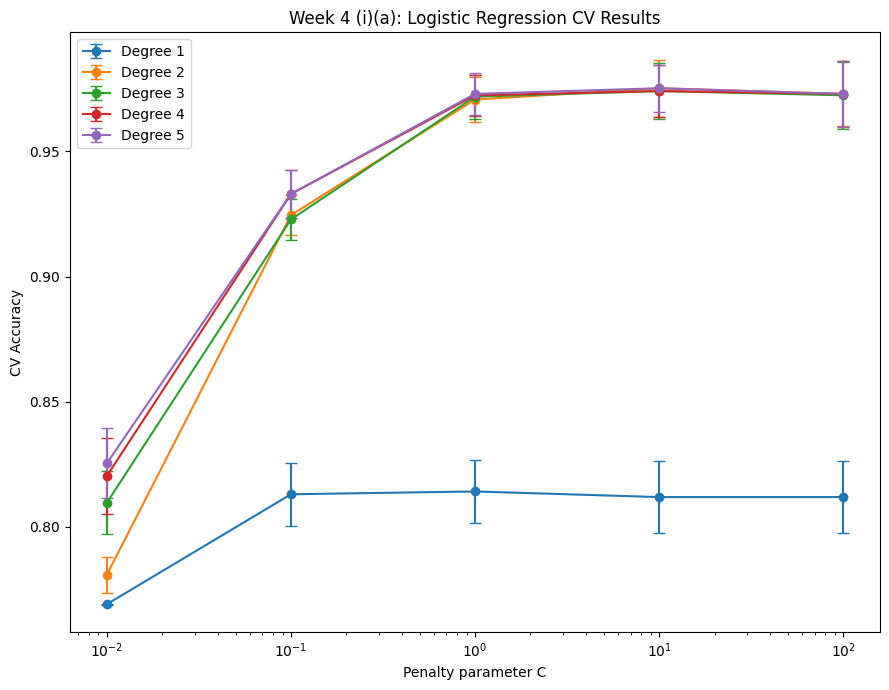


Best hyperparameters by CV accuracy:
degree       2.000000
C           10.000000
mean_acc     0.975232
std_acc      0.011442
Name: 8, dtype: float64


In [2]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df = pd.read_excel('week4_dataset1.xlsx')

# Assume: first 2 columns = features, last column = target class
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

# Check class balance and feature range
print("First few rows:\n", df.head())
print("Class distribution:", pd.Series(y).value_counts())
print("Feature stats:\n", pd.DataFrame(X).describe())

# Set up reasonable polynomial degrees and C values
degrees = [1, 2, 3, 4, 5]
C_values = [0.01, 0.1, 1, 10, 100]

# For results
results = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    for C in C_values:
        # Use l2 regularization by default, change max_iter for stability
        model = LogisticRegression(C=C, max_iter=5000)
        # Use 5-fold stratified cross-validation, accuracy as metric
        scores = cross_val_score(model, X_poly, y, cv=5, scoring='accuracy')
        mean_acc = np.mean(scores)
        std_acc = np.std(scores)
        results.append({'degree': degree, 'C': C, 'mean_acc': mean_acc, 'std_acc': std_acc})

# Convert results for easy plotting
res_df = pd.DataFrame(results)
plt.figure(figsize=(9,7))
for degree in degrees:
    subset = res_df[res_df['degree']==degree]
    plt.errorbar(subset['C'], subset['mean_acc'], yerr=subset['std_acc'], label=f'Degree {degree}', marker='o', capsize=4)
plt.xscale('log')
plt.xlabel('Penalty parameter C')
plt.ylabel('CV Accuracy')
plt.title('Week 4 (i)(a): Logistic Regression CV Results')
plt.legend()
plt.tight_layout()
plt.show()

# Print the best combo for reference
best = res_df.loc[res_df['mean_acc'].idxmax()]
print("\nBest hyperparameters by CV accuracy:")
print(best)


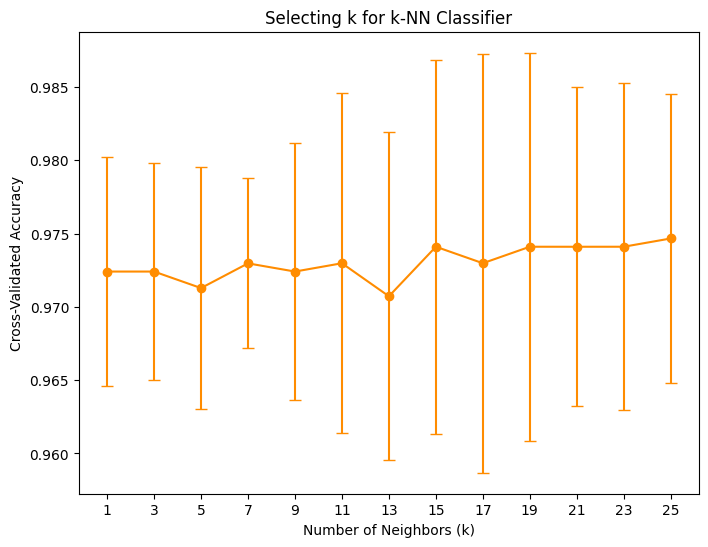

Best k is 25 with CV accuracy 0.975


In [6]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load dataset 1
df = pd.read_excel('week4_dataset1.xlsx')
X = df.iloc[:, :2].values  # Use raw features (no polynomial augmentation)
y = df.iloc[:, 2].values

# Test k values from 1 to 25 (odd numbers preferred often)
k_values = list(range(1, 26, 2))
mean_acc = []
std_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    mean_acc.append(np.mean(scores))
    std_acc.append(np.std(scores))

# Plot accuracy with error bars over k to pick best k
plt.figure(figsize=(8,6))
plt.errorbar(k_values, mean_acc, yerr=std_acc, fmt='-o', color='darkorange', capsize=4)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Selecting k for k-NN Classifier')
plt.xticks(k_values)
plt.show()

# Best k based on highest mean accuracy
best_k_index = np.argmax(mean_acc)
best_k = k_values[best_k_index]
best_acc = mean_acc[best_k_index]

print(f"Best k is {best_k} with CV accuracy {best_acc:.3f}")


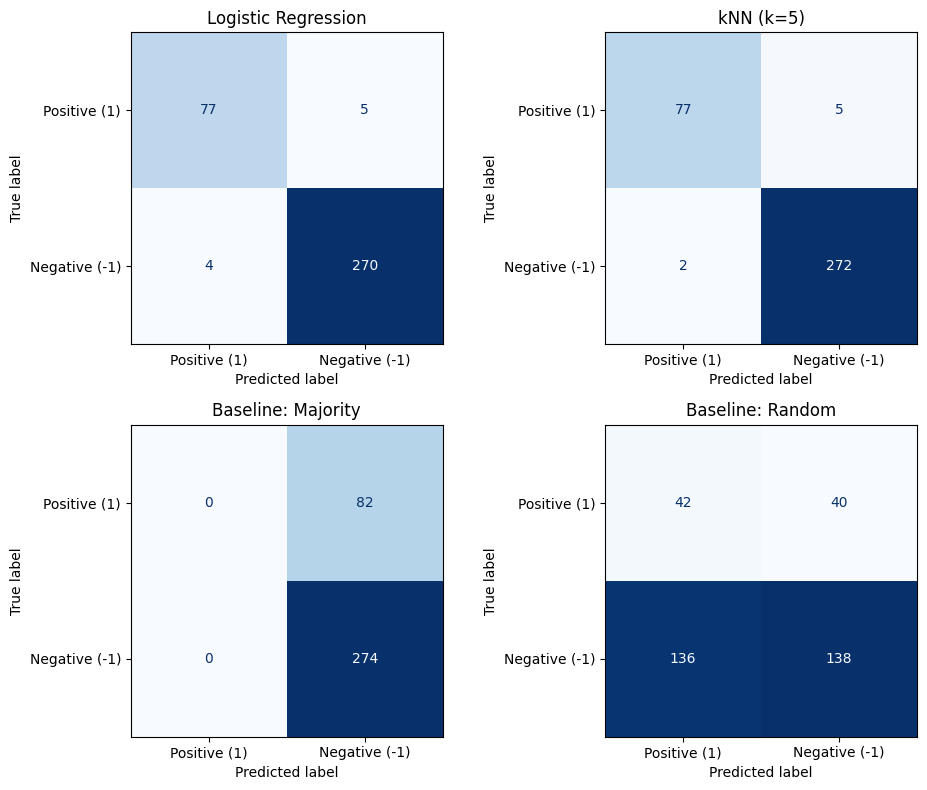

In [7]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('week4_dataset1.xlsx')
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

# Split into training and testing for fair comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Logistic Regression (best from part a) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

log_model = LogisticRegression(C=10, max_iter=5000)
log_model.fit(X_train_poly, y_train)
y_pred_log = log_model.predict(X_test_poly)

# --- kNN (best k from part b) ---
best_k = 5  # update with your actual best k from (b)
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# --- Baseline 1: Always predicts most frequent class ---
baseline_majority = DummyClassifier(strategy='most_frequent')
baseline_majority.fit(X_train, y_train)
y_pred_base_majority = baseline_majority.predict(X_test)

# --- Baseline 2: Random predictions ---
baseline_random = DummyClassifier(strategy='uniform', random_state=42)
baseline_random.fit(X_train, y_train)
y_pred_base_random = baseline_random.predict(X_test)

# --- Plot all confusion matrices side-by-side ---
fig, axes = plt.subplots(2, 2, figsize=(10,8))
titles = ['Logistic Regression', f'kNN (k={best_k})', 'Baseline: Majority', 'Baseline: Random']
preds = [y_pred_log, y_pred_knn, y_pred_base_majority, y_pred_base_random]

for ax, title, pred in zip(axes.ravel(), titles, preds):
    cm = confusion_matrix(y_test, pred, labels=[1, -1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive (1)', 'Negative (-1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


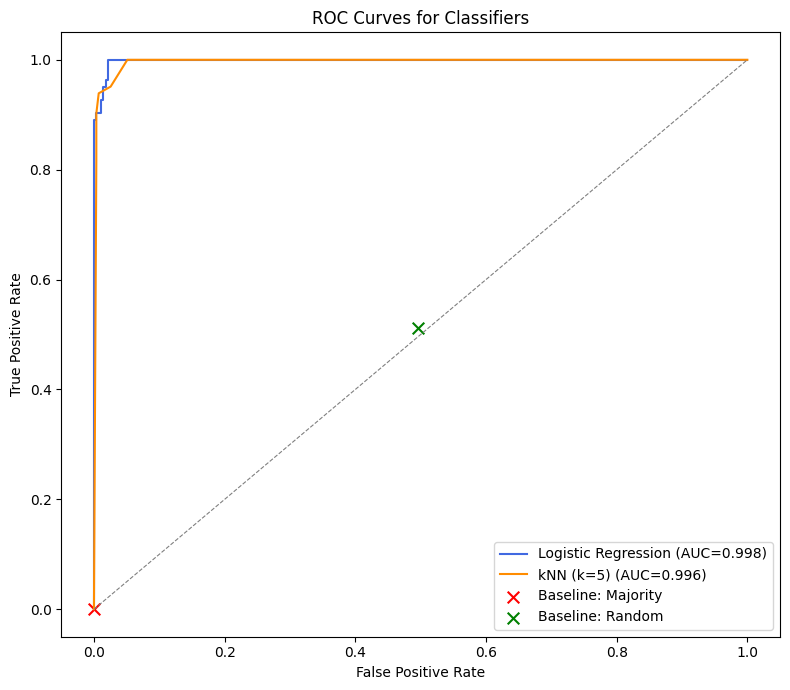

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

# Load and split data (same as previous part)
df = pd.read_excel('week4_dataset1.xlsx')
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Logistic Regression predictions (use probabilities)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
logreg = LogisticRegression(C=10, max_iter=5000)
logreg.fit(X_train_poly, y_train)
prob_log = logreg.predict_proba(X_test_poly)[:, 1]

# kNN predictions (use probabilities)
best_k = 5
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
prob_knn = knn.predict_proba(X_test)[:, 1]

# Baseline: Majority
dummy_maj = DummyClassifier(strategy='most_frequent')
dummy_maj.fit(X_train, y_train)
prob_maj = dummy_maj.predict_proba(X_test)[:, 1]

# Baseline: Random
dummy_rand = DummyClassifier(strategy='uniform', random_state=42)
dummy_rand.fit(X_train, y_train)
prob_rand = dummy_rand.predict_proba(X_test)[:, 1]

# ROC curve calculations
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log, pos_label=1)
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn, pos_label=1)

# Baseline points: single FPR/TPR since they're not probabilistic
maj_pred = dummy_maj.predict(X_test)
rand_pred = dummy_rand.predict(X_test)
fpr_maj = np.sum((maj_pred == 1) & (y_test == -1)) / np.sum(y_test == -1)
tpr_maj = np.sum((maj_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
fpr_rand = np.sum((rand_pred == 1) & (y_test == -1)) / np.sum(y_test == -1)
tpr_rand = np.sum((rand_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)

# Plot ROC curves
plt.figure(figsize=(8,7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc(fpr_log, tpr_log):.3f})', color='royalblue')
plt.plot(fpr_knn, tpr_knn, label=f'kNN (k={best_k}) (AUC={auc(fpr_knn, tpr_knn):.3f})', color='darkorange')
plt.scatter([fpr_maj], [tpr_maj], c='red', label='Baseline: Majority', s=70, marker='x')
plt.scatter([fpr_rand], [tpr_rand], c='green', label='Baseline: Random', s=70, marker='x')
plt.plot([0,1],[0,1],'--',color='gray',lw=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classifiers')
plt.legend()
plt.tight_layout()
plt.show()


First few rows:
    # id:17-17-17-0   Unnamed: 1  Unnamed: 2
0             -0.09        0.22           1
1              0.20        0.98           1
2             -0.40       -0.04          -1
3              0.14        0.77           1
4              0.12        0.53          -1
Class distribution:  1    507
-1    239
Name: count, dtype: int64
Feature stats:
                 0           1
count  746.000000  746.000000
mean     0.009142    0.004155
std      0.578277    0.568804
min     -1.000000   -1.000000
25%     -0.510000   -0.500000
50%      0.075000    0.010000
75%      0.460000    0.490000
max      1.000000    1.000000


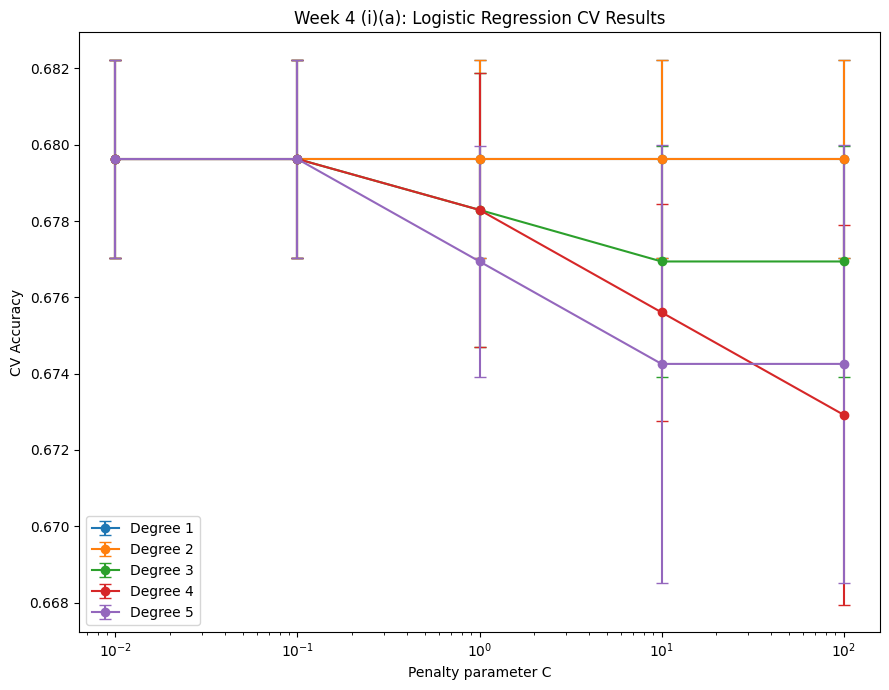


Best hyperparameters by CV accuracy:
degree      1.000000
C           0.010000
mean_acc    0.679624
std_acc     0.002606
Name: 0, dtype: float64


In [9]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df = pd.read_excel('week4_dataset2.xlsx')

# Assume: first 2 columns = features, last column = target class
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

# Check class balance and feature range
print("First few rows:\n", df.head())
print("Class distribution:", pd.Series(y).value_counts())
print("Feature stats:\n", pd.DataFrame(X).describe())

# Set up reasonable polynomial degrees and C values
degrees = [1, 2, 3, 4, 5]
C_values = [0.01, 0.1, 1, 10, 100]

# For results
results = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    for C in C_values:
        # Use l2 regularization by default, change max_iter for stability
        model = LogisticRegression(C=C, max_iter=5000)
        # Use 5-fold stratified cross-validation, accuracy as metric
        scores = cross_val_score(model, X_poly, y, cv=5, scoring='accuracy')
        mean_acc = np.mean(scores)
        std_acc = np.std(scores)
        results.append({'degree': degree, 'C': C, 'mean_acc': mean_acc, 'std_acc': std_acc})

# Convert results for easy plotting
res_df = pd.DataFrame(results)
plt.figure(figsize=(9,7))
for degree in degrees:
    subset = res_df[res_df['degree']==degree]
    plt.errorbar(subset['C'], subset['mean_acc'], yerr=subset['std_acc'], label=f'Degree {degree}', marker='o', capsize=4)
plt.xscale('log')
plt.xlabel('Penalty parameter C')
plt.ylabel('CV Accuracy')
plt.title('Week 4 (i)(a): Logistic Regression CV Results')
plt.legend()
plt.tight_layout()
plt.show()

# Print the best combo for reference
best = res_df.loc[res_df['mean_acc'].idxmax()]
print("\nBest hyperparameters by CV accuracy:")
print(best)


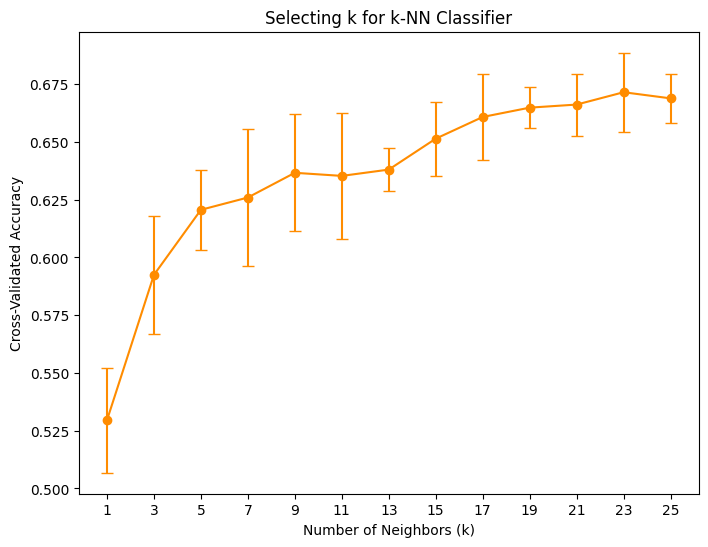

Best k is 23 with CV accuracy 0.672


In [10]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load dataset 1
df = pd.read_excel('week4_dataset2.xlsx')
X = df.iloc[:, :2].values  # Use raw features (no polynomial augmentation)
y = df.iloc[:, 2].values

# Test k values from 1 to 25 (odd numbers preferred often)
k_values = list(range(1, 26, 2))
mean_acc = []
std_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    mean_acc.append(np.mean(scores))
    std_acc.append(np.std(scores))

# Plot accuracy with error bars over k to pick best k
plt.figure(figsize=(8,6))
plt.errorbar(k_values, mean_acc, yerr=std_acc, fmt='-o', color='darkorange', capsize=4)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Selecting k for k-NN Classifier')
plt.xticks(k_values)
plt.show()

# Best k based on highest mean accuracy
best_k_index = np.argmax(mean_acc)
best_k = k_values[best_k_index]
best_acc = mean_acc[best_k_index]

print(f"Best k is {best_k} with CV accuracy {best_acc:.3f}")


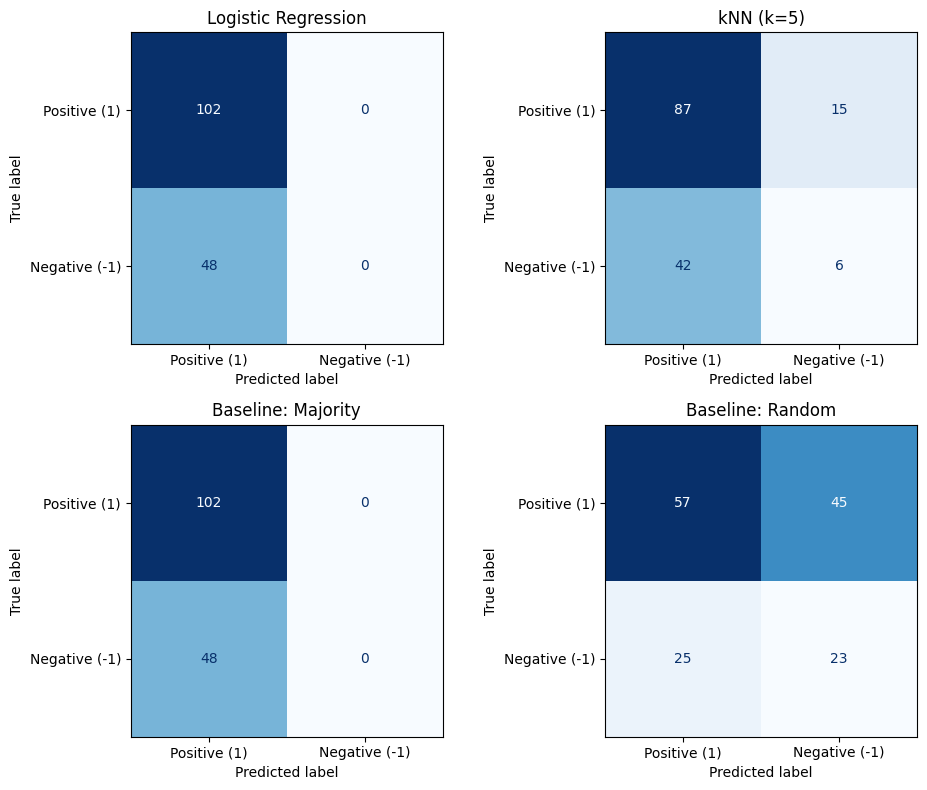

In [11]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('week4_dataset2.xlsx')
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

# Split into training and testing for fair comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Logistic Regression (best from part a) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

log_model = LogisticRegression(C=10, max_iter=5000)
log_model.fit(X_train_poly, y_train)
y_pred_log = log_model.predict(X_test_poly)

# --- kNN (best k from part b) ---
best_k = 5  # update with your actual best k from (b)
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# --- Baseline 1: Always predicts most frequent class ---
baseline_majority = DummyClassifier(strategy='most_frequent')
baseline_majority.fit(X_train, y_train)
y_pred_base_majority = baseline_majority.predict(X_test)

# --- Baseline 2: Random predictions ---
baseline_random = DummyClassifier(strategy='uniform', random_state=42)
baseline_random.fit(X_train, y_train)
y_pred_base_random = baseline_random.predict(X_test)

# --- Plot all confusion matrices side-by-side ---
fig, axes = plt.subplots(2, 2, figsize=(10,8))
titles = ['Logistic Regression', f'kNN (k={best_k})', 'Baseline: Majority', 'Baseline: Random']
preds = [y_pred_log, y_pred_knn, y_pred_base_majority, y_pred_base_random]

for ax, title, pred in zip(axes.ravel(), titles, preds):
    cm = confusion_matrix(y_test, pred, labels=[1, -1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive (1)', 'Negative (-1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (ipython-input-1603544838.py, line 12)

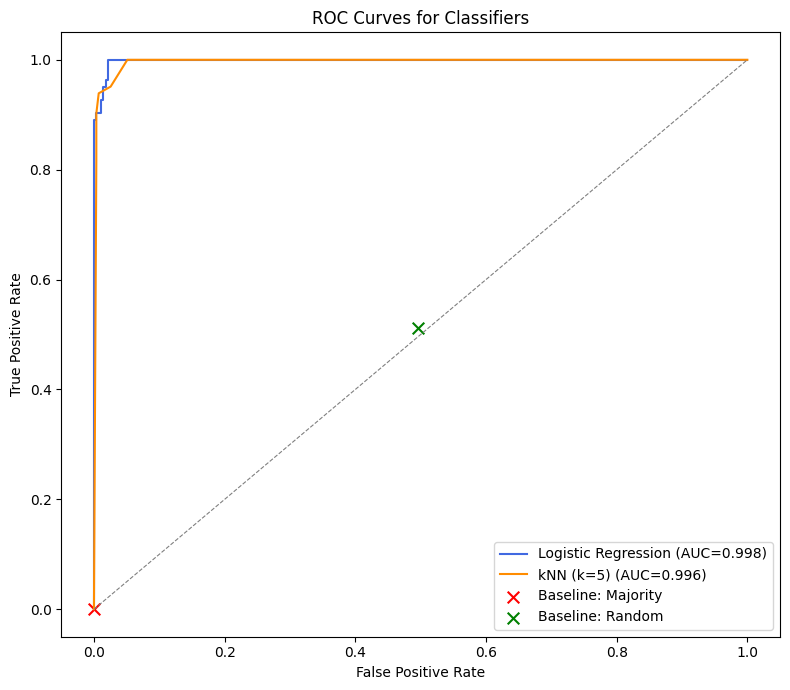

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

# Load and split data (same as previous part)
df = pd.read_excel('week4_dataset1.xlsx')
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Logistic Regression predictions (use probabilities)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
logreg = LogisticRegression(C=10, max_iter=5000)
logreg.fit(X_train_poly, y_train)
prob_log = logreg.predict_proba(X_test_poly)[:, 1]

# kNN predictions (use probabilities)
best_k = 5
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
prob_knn = knn.predict_proba(X_test)[:, 1]

# Baseline: Majority
dummy_maj = DummyClassifier(strategy='most_frequent')
dummy_maj.fit(X_train, y_train)
prob_maj = dummy_maj.predict_proba(X_test)[:, 1]

# Baseline: Random
dummy_rand = DummyClassifier(strategy='uniform', random_state=42)
dummy_rand.fit(X_train, y_train)
prob_rand = dummy_rand.predict_proba(X_test)[:, 1]

# ROC curve calculations
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log, pos_label=1)
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn, pos_label=1)

# Baseline points: single FPR/TPR since they're not probabilistic
maj_pred = dummy_maj.predict(X_test)
rand_pred = dummy_rand.predict(X_test)
fpr_maj = np.sum((maj_pred == 1) & (y_test == -1)) / np.sum(y_test == -1)
tpr_maj = np.sum((maj_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
fpr_rand = np.sum((rand_pred == 1) & (y_test == -1)) / np.sum(y_test == -1)
tpr_rand = np.sum((rand_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)

# Plot ROC curves
plt.figure(figsize=(8,7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc(fpr_log, tpr_log):.3f})', color='royalblue')
plt.plot(fpr_knn, tpr_knn, label=f'kNN (k={best_k}) (AUC={auc(fpr_knn, tpr_knn):.3f})', color='darkorange')
plt.scatter([fpr_maj], [tpr_maj], c='red', label='Baseline: Majority', s=70, marker='x')
plt.scatter([fpr_rand], [tpr_rand], c='green', label='Baseline: Random', s=70, marker='x')
plt.plot([0,1],[0,1],'--',color='gray',lw=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classifiers')
plt.legend()
plt.tight_layout()
plt.show()
